In [22]:
import torch 
import torch.nn as nn
import torch.optim as optim 


import torchvision # A special pytorch library explicitly made for Computer Vision 


### Why to choose TorchVision - 
#### Because it already have various datasets like CIFAR10 , MNIST
#### It contain pre trained CNN's , so that our working computer/ Laptop takes less amount of complexity of CNN Models
#### It has in-built tools for handling utilities for image tranformation.

In [23]:
#Taking CIFAR10 Dataset as a begineer level 
from torchvision.datasets import CIFAR10


In [24]:
#DataSet and Dataloaders 
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# image would be scaled first in range (0 , 1) and then it would be normalized in range (-1,1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5 , 0.5 , 0.5) , (0.5 , 0.5 ,0.5))

])

#Need to get training set 
trainset = CIFAR10(root = "./data" , train= True , download = True , transform= transform)
#And the tesing set 
testset = CIFAR10(root = "./data" , train= False , download = True , transform= transform)



In [25]:
trainloader = DataLoader(trainset , batch_size= 64 , shuffle= True)
testloader = DataLoader(testset , batch_size = 64 , shuffle= False)


### Building the CNN 

In [26]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN , self).__init__()


        self.convo_layers = nn.Sequential(
            nn.Conv2d(3 ,32 , kernel_size = 3 , padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2), # kernel size = 2 , stride = 2

            #Second Convolutional Layer 
            nn.Conv2d(32 ,64 , kernel_size = 3 , padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            #Third Convolutional layer
            nn.Conv2d(64 ,128 , kernel_size = 3 , padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        #Making up the Fully Connected Layers 
        self.fc_layer = nn.Sequential(
            nn.Linear(4*4*128 , 256),
            nn.ReLU(),

            nn.Linear(256 , 10)

        )

    
    def forward(self , x):
        x = self.convo_layers(x)
        x = x.view(x.size(0) , -1 ) #flattening
        x = self.fc_layer(x)

        return x 
    


In [27]:
model = CNN()
criterion= nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())


### Training and validating the CNN 

In [28]:
epochs = 10

train_losses = []

val_losses = []

val_accuracies = []

for epoch in range(epochs):

    # ======================

    # TRAINING

    # ======================

    model.train()

    running_train_loss = 0.0

    for images, labels in trainloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(trainloader)

    # ======================

    # VALIDATION

    # ======================

    model.eval()

    running_val_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(testloader)

    val_accuracy = 100 * correct / total

    train_losses.append(avg_train_loss)

    val_losses.append(avg_val_loss)

    val_accuracies.append(val_accuracy)

    print(

        f"Epoch [{epoch+1}/{epochs}] | "

        f"Train Loss: {avg_train_loss:.4f} | "

        f"Val Loss: {avg_val_loss:.4f} | "

        f"Val Accuracy: {val_accuracy:.2f}%"

    )

Epoch [1/10] | Train Loss: 1.3874 | Val Loss: 1.2438 | Val Accuracy: 55.61%
Epoch [2/10] | Train Loss: 0.9593 | Val Loss: 0.9921 | Val Accuracy: 65.97%
Epoch [3/10] | Train Loss: 0.7641 | Val Loss: 0.7765 | Val Accuracy: 73.40%
Epoch [4/10] | Train Loss: 0.6324 | Val Loss: 0.7898 | Val Accuracy: 73.25%
Epoch [5/10] | Train Loss: 0.5257 | Val Loss: 0.7611 | Val Accuracy: 74.58%
Epoch [6/10] | Train Loss: 0.4305 | Val Loss: 0.7833 | Val Accuracy: 75.37%
Epoch [7/10] | Train Loss: 0.3532 | Val Loss: 0.7602 | Val Accuracy: 76.16%
Epoch [8/10] | Train Loss: 0.2785 | Val Loss: 0.8593 | Val Accuracy: 76.22%
Epoch [9/10] | Train Loss: 0.2156 | Val Loss: 0.9124 | Val Accuracy: 75.85%
Epoch [10/10] | Train Loss: 0.1694 | Val Loss: 1.0590 | Val Accuracy: 75.87%


### Evaluating the Model

In [29]:
correct_labels = 0 
total_labels = 0 

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _ , predicted = torch.max(outputs , 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)


print(f"accuracy ={correct_labels/total_labels *100}")

accuracy =75.87


### Visualizing the Model Work

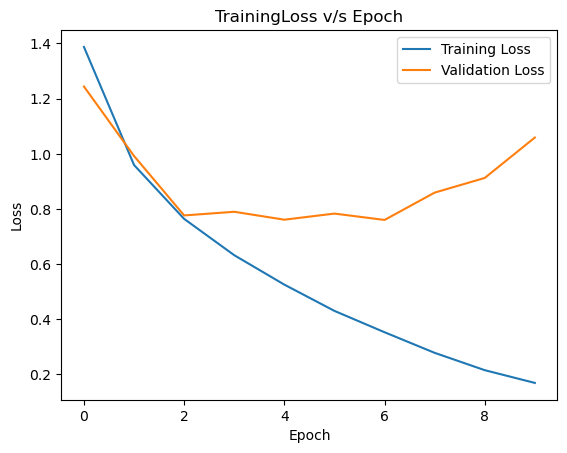

In [32]:
import matplotlib.pyplot as plt 

plt.plot(train_losses , label = "Training Loss")
plt.plot(val_losses , label = "Validation Loss")

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title("TrainingLoss v/s Epoch")
plt.legend()
plt.show()

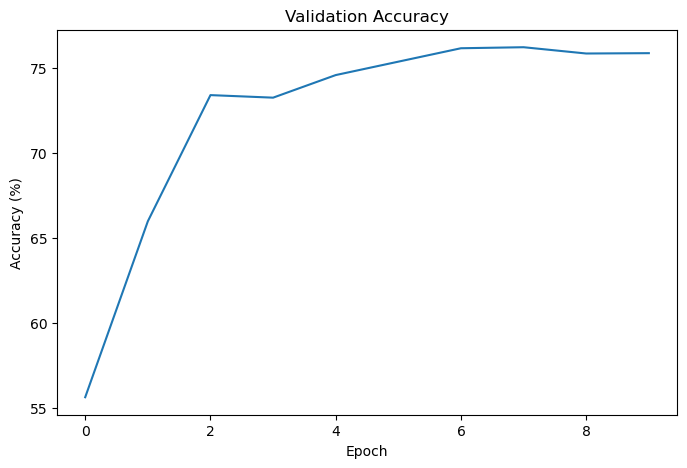

In [33]:
#Accuracy Graph - 

plt.figure(figsize=(8,5))

plt.plot(val_accuracies)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Validation Accuracy")

plt.show()

In [30]:
#Saving the model 
torch.save(model.state_dict() , "Cnn_Model.pth")
print("Model saved successfully!")

Model saved successfully!
